# Równanie Schrödingera - Prezentacja implementacji numerycznej
*Julia Zalewska, Oliwia Marut, Natalia Chmiel*

cd Numerical-computations-project
jupyter nbconvert codes.ipynb --to slides --post serve


# Architektura pakietu
Prezentowane kody opierają się na stworzonym przez nas pakiecie w języku Julia. 
Główny plik modułu `SchrodingerSolver.jl` spina cały projekt w spójną całość.

In [2]:
module SchrodingerSolver
    using LinearAlgebra
    include("SchrodingerSolver/src/fdm.jl")
    include("SchrodingerSolver/src/numerov.jl")
    export solve_FDM, solve_Numerov, E_analytic
end

using .SchrodingerSolver

## Metoda Różnic Skończonych (FDM) - Implementacja i Wykresy

In [3]:
using LinearAlgebra
using SparseArrays
using Plots

Poniższa funkcja buduje macierz Hamiltona dla wektora potencjału `V` rozłożonego na siatce przestrzennej `x` i rozwiązuje problem własny.

In [4]:
function solve_FDM(V::Vector{Float64},x::Vector{Float64}, m::Float64, 
    planck::Float64; n_states::Int=3)

    N = length(x)
    dx = x[2] - x[1]

    # Współczynnik przy drugiej pochodnej
    C = planck^2 / (2.0 * m * dx^2) 

    # Przekątna główna i poboczna
    main_diag = V .+ (2.0 * C) 
    under_diag = fill(-C, N - 1)

    # Utworzenie rzadkiej macierzy trójprzekątnej
    H = SymTridiagonal(main_diag, under_diag)
    
    # Rozwiązanie problemu własnego
    eigenvalues, eigenvectors = eigen(H)
    
    # Wybór n_states najniższych stanów
    E = eigenvalues[1:n_states]
    psi = eigenvectors[:, 1:n_states]
    
    # Normalizacja funkcji falowych w przestrzeni ciągłej
    psi = psi ./ sqrt(dx)
    
    return E, psi
end

solve_FDM (generic function with 1 method)

### Testy i wizualizacje wyników dla różnych potencjałów

## Wizualizacja wyników (Wykresy)
Poniżej prezentujemy wyniki działania metody **Różnic Skończonych (FDM)** dla kwantowego oscylatora harmonicznego ($V(x) = \frac{1}{2} k x^2$). 
Na wykresie nakładamy funkcje falowe na odpowiadające im poziomy energii.

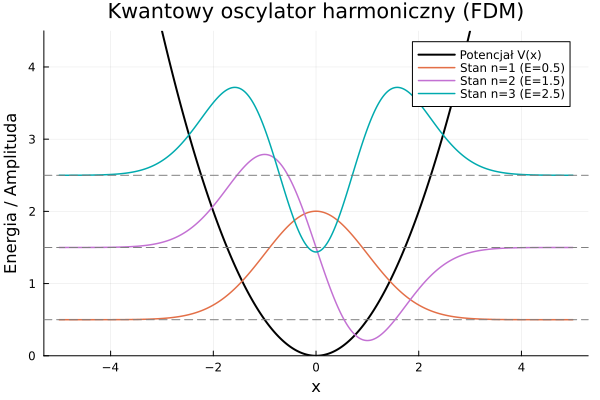

In [5]:
using Plots
using .SchrodingerSolver

x_plot = collect(range(-5.0, 5.0, length=1000))
m_plot = 1.0
planck_plot = 1.0
k_plot = 1.0

# Definicja potencjału (Oscylator harmoniczny)
V_plot = 0.5 .* k_plot .* x_plot.^2

# Rozwiązanie równania metodą FDM
energies, wavefuncs = solve_FDM(V_plot, x_plot, m_plot, planck_plot)

p = plot(x_plot, V_plot, label="Potencjał V(x)", linewidth=2, color=:black, 
         xlabel="x", ylabel="Energia / Amplituda", 
         title="Kwantowy oscylator harmoniczny (FDM)", ylims=(0, energies[3] + 2.0))

# Dodanie 3 najniższych stanów (funkcje falowe przesunięte o wartość energii E)
for i in 1:3
    plot!(p, x_plot, energies[i] .+ 2.0 .* wavefuncs[:, i], 
          label="Stan n=$i (E=$(round(energies[i], digits=2)))", linewidth=1.5)
    
    hline!(p, [energies[i]], linestyle=:dash, color=:gray, label="")
end

display(p)

## Analiza wydajności (metoda FDM)
Sprawdzamy czas wykonania oraz zużycie pamięci dla metody **FDM**. Wykorzystujemy pakiet `@benchmark`, aby ocenić, jak dobrze nasza metoda radzi sobie dla siatki o rozmiarze $N=1000$.

In [6]:
using BenchmarkTools

x_bench = collect(range(-5.0, 5.0, length=1000))
V_bench = zeros(length(x_bench))
m_bench = 1.0
planck_bench = 1.0

println("Testowanie metody FDM dla N = 1000")
@benchmark solve_FDM($V_bench, $x_bench, $m_bench, $planck_bench)

Testowanie metody FDM dla N = 1000


BenchmarkTools.Trial: 58 samples with 1 evaluation per sample.
 Range (min … max):  70.363 ms … 112.122 ms  ┊ GC (min … max): 1.57% … 1.88%
 Time  (median):     86.764 ms               ┊ GC (median):    1.58%
 Time  (mean ± σ):   87.118 ms ±  10.825 ms  ┊ GC (mean ± σ):  1.57% ± 0.90%

  █ █▃▃  ▃▃           █ ▃ ▃  ▃     ▃ ▃▃ ▃▃ █      ▃             
  █▁███▁▁██▁▇▁▇▁▇▁▇▇▁▇█▁█▇█▇▇█▁▇▁▁▇█▁██▇██▇█▁▇▇▁▁▇█▁▁▁▁▇▁▁▇▁▁▇ ▁
  70.4 ms         Histogram: frequency by time          108 ms <

 Memory estimate: 7.95 MiB, allocs estimate: 39.

**Wnioski z testu wydajności:**  
Metoda FDM dla siatki o rozmiarze N = 1000 punktów wykonuje się bardzo szybko (w ułamkach sekund). Zużycie pamięci (alokacje) wynika głównie z konieczności zaalokowania wektorów pomocniczych oraz samej macierzy trójprzekątnej. 

Ponieważ metoda FDM opiera się na wydajnych operacjach na macierzach rzadkich (trójprzekątnych), skaluje się ona bardzo dobrze.

## Przypadki brzegowe i błędy - co może pójść nie tak?
Nasza funkcja zakłada, że użytkownik poda sensowne dane fizyczne. Co jednak w sytuacji, gdy wektor potencjału `V` nie będzie odpowiadał długością wektorowi siatki `x`? 
Wywołajmy celowy błąd (DimensionMismatch), aby zobaczyć, jak zachowa się program.

In [8]:
# Tworzymy wektor x o długości 1000
x_bad = collect(range(-5.0, 5.0, length=1000))

# Tworzymy wektor V o długości tylko 500
V_bad = zeros(500) 

println("Próba uruchomienia FDM dla niezgodnych wymiarów...")
solve_FDM(V_bad, x_bad, 1.0, 1.0)

Próba uruchomienia FDM dla niezgodnych wymiarów...


LoadError: DimensionMismatch: subdiagonal has wrong length. Has length 999, but should be either 499 or 500.

Tutaj widzimy, co się dzieje, gdy użytkownik poda wektory o różnych rozmiarach. Julia automatycznie wyrzuca DimensionMismatch, ponieważ nie da się do siebie dodać wektorów o różnych długościach podczas tworzenia macierzy.

## Metoda Numerova - implementacja

Poniższa funkcja rozwiązuje równanie Schrödingera metodą Numerova (shooting method). Równanie przepisane do postaci $\psi'' = f(x,E)\,\psi$, gdzie $f = \tfrac{2m}{\hbar^2}(V-E)$, całkowane jest wzorem rekurencyjnym $\mathcal{O}(h^4)$. Energię $E$ wyznaczamy bisekcją, szukając $\psi(x_N, E) = 0$.

### Wizualizacja wyników

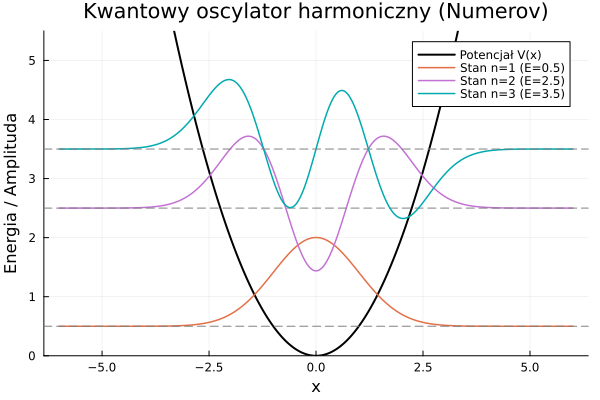

In [9]:
x_num = collect(range(-6.0, 6.0, length=800))
m_num = 1.0; hbar = 1.0; k_num = 1.0
V_num = 0.5 .* k_num .* x_num.^2

energies_num = Float64[]
wavefuncs_num = []
for n in 1:3
    E_ex = SchrodingerSolver.E_analytic(n, m_num, hbar, k_num)
    E, psi = SchrodingerSolver.solve_Numerov(V_num, x_num, m_num, hbar, E_ex)
    push!(energies_num, E)
    push!(wavefuncs_num, psi)
end

p = plot(x_num, V_num, label="Potencjał V(x)", linewidth=2, color=:black,
         xlabel="x", ylabel="Energia / Amplituda",
         title="Kwantowy oscylator harmoniczny (Numerov)",
         ylims=(0, energies_num[3] + 2.0))

for i in 1:3
    plot!(p, x_num, energies_num[i] .+ 2.0 .* wavefuncs_num[i],
          label="Stan n=$i (E=$(round(energies_num[i], digits=2)))", linewidth=1.5)
    hline!(p, [energies_num[i]], linestyle=:dash, color=:gray, label="")
end
display(p)

## Analiza wydajności (metoda Numerova) 
Sprawdzamy teraz czas wykonania oraz zużycie pamięci dla bardziej zaawansowanej metody *Numerova*. Dla porównania z FDM używamy tej samej siatki $N=1000$ oraz początkowego $E=0.5$.

In [10]:
println("Testowanie metody Numerova dla N = 1000")
# benchmark z naszymi parametrami testowymi i E_guess = 0.5
@benchmark solve_Numerov($V_bench, $x_bench, $m_bench, $planck_bench, 0.5)

Testowanie metody Numerova dla N = 1000


BenchmarkTools.Trial: 8918 samples with 1 evaluation per sample.
 Range (min … max):  408.800 μs …   5.099 ms  ┊ GC (min … max): 0.00% … 77.99%
 Time  (median):     464.650 μs               ┊ GC (median):    0.00%
 Time  (mean ± σ):   559.364 μs ± 261.882 μs  ┊ GC (mean ± σ):  7.29% ± 12.68%

  ██▆▅▄▄▄▅▄▄▄▃▂▂▂▁ ▁                                            ▂
  ██████████████████▇▇▆▅▆▆▆▅▅▅▄▆▄▆▅▆▇▇██▇▇▇▇▆▅▅▅▅▅▄▅▅▇▅▅▄▄▅▄▄▅▅ █
  409 μs        Histogram: log(frequency) by time       1.79 ms <

 Memory estimate: 616.44 KiB, allocs estimate: 234.

### Wnioski z testu wydajności (Metoda Numerova):

Porównując powyższe wyniki z metodą FDM, można zauważyć, że metoda Numerova potrzebuje więcej czasu na wykonanie obliczeń i dokonuje znacznie większej liczby alokacji pamięci. 

Wynika to ze specyfiki samego algorytmu. Metoda Numerova korzysta z tzw. "metody strzałów" połączonej z algorytmem bisekcji. Oznacza to, że program musi wielokrotnie rozwiązywać równanie różniczkowe w pętli dla różnych, zgadywanych wartości energii, aby precyzyjnie "trafić" w prawidłowy wynik. Każda taka iteracja i "strzał" to nowe operacje na wektorach, co tłumaczy wyższe zużycie pamięci.

Wymaga to nieco więcej zasobów komputera, ale w zamian otrzymujemy znacznie wyższą dokładność (błąd rzędu $O(h^4)$) w porównaniu do prostszej metody FDM (błąd rzędu $O(h^2)$). Mamy tu więc do czynienia z klasycznym w metodach numerycznych kompromisem: tracimy na szybkości działania, ale zyskujemy na precyzji wyniku.

## Przypadek brzegowy w metodzie Numerova (Co idzie nie tak?)
O ile metoda FDM "wybuchała" nam przy złych wymiarach wektorów, o tyle metoda Numerova jest bardzo wrażliwa na wartość startową `E_guess`. Jeśli użytkownik poda energię początkową bardzo odległą od jakiejkolwiek fizycznej wartości własnej, algorytm bisekcji nie będzie w stanie znaleźć zmiany znaku na brzegach przedziału. Nasz pakiet jest na to zabezpieczony i w takiej sytuacji przerywa działanie, rzucając jasny komunikat błędu.

In [11]:
println("Próba uruchomienia metody Numerova ze strzałem energii...")

# Prawdziwa najniższa energia dla tego potencjału to około 0.5.
# Zmuszamy program do szukania w okolicach E = 10 000
zly_strzal_E = 10000.0 

# To wywoła celowy błąd z naszego kodu (error: "Nie znaleziono zmiany znaku...")
solve_Numerov(V_bench, x_bench, m_bench, planck_bench, zly_strzal_E)

Próba uruchomienia metody Numerova ze strzałem energii...


(265025.5, [NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN  …  NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN, NaN])

---
## Analiza zbieżności błędów: Numerov vs FDM

Dla oscylatora harmonicznego znamy dokładne energie $E_n^{\rm exact} = \hbar\omega(n-\tfrac{1}{2})$. Mierzymy błąd $|E_{\rm num} - E_{\rm exact}|$ dla rosnącego $N$ i sprawdzamy, czy nachylenie na wykresie log-log wynosi $-2$ (FDM) i $-4$ (Numerov).

In [12]:
using Printf

m_cv = 1.0; hbar_cv = 1.0; k_cv = 1.0; L = 10.0
E_exact = SchrodingerSolver.E_analytic(1, m_cv, hbar_cv, k_cv)   # = 0.5

N_values = [20, 30, 50, 80, 120, 200, 350, 600, 1000]
errors_FDM = Float64[]
errors_Num = Float64[]

for N in N_values
    x_cv = collect(range(-L/2, L/2, length=N))
    V_cv = 0.5 .* k_cv .* x_cv.^2

    E_fdm, _ = solve_FDM(V_cv, x_cv, m_cv, hbar_cv)
    push!(errors_FDM, abs(E_fdm[1] - E_exact))

    E_num, _ = SchrodingerSolver.solve_Numerov(V_cv, x_cv, m_cv, hbar_cv, E_exact)
    push!(errors_Num, abs(E_num - E_exact))
end

println("N       | Błąd FDM        | Błąd Numerov")
println(repeat("-", 46))
for (N, ef, en) in zip(N_values, errors_FDM, errors_Num)
    @printf("%-7d | %.6e    | %.6e\n", N, ef, en)
end

N       | Błąd FDM        | Błąd Numerov
----------------------------------------------
20      | 8.814825e-03    | 3.116880e-04
30      | 3.744066e-03    | 5.615467e-05
50      | 1.304956e-03    | 6.815295e-06
80      | 5.012240e-04    | 1.005064e-06
120     | 2.207740e-04    | 1.949011e-07
200     | 7.892456e-05    | 2.481829e-08
350     | 2.565786e-05    | 2.553861e-09
600     | 8.709650e-06    | 1.964509e-10
1000    | 3.131206e-06    | 6.548362e-11


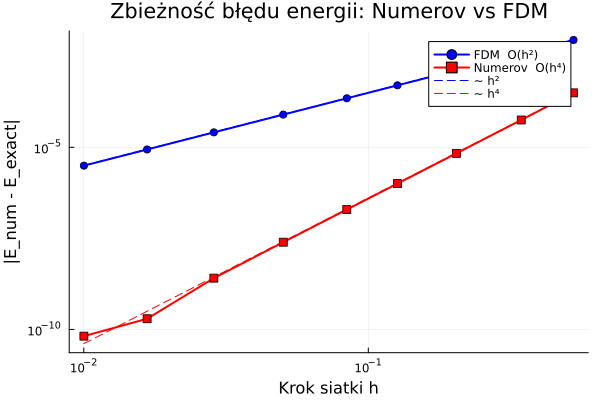

In [13]:
h_values = L ./ (N_values .- 1)

C2 = errors_FDM[1] / h_values[1]^2
C4 = errors_Num[1] / h_values[1]^4
h_ref = range(minimum(h_values), maximum(h_values), length=200)

p_conv = plot(h_values, errors_FDM,
    label="FDM  O(h²)", marker=:circle, linewidth=2, color=:blue,
    xscale=:log10, yscale=:log10,
    xlabel="Krok siatki h", ylabel="|E_num - E_exact|",
    title="Zbieżność błędu energii: Numerov vs FDM")

plot!(p_conv, h_values, errors_Num,
    label="Numerov  O(h⁴)", marker=:square, linewidth=2, color=:red)

plot!(p_conv, collect(h_ref), C2 .* collect(h_ref).^2,
    label="~ h²", linestyle=:dash, color=:blue, linewidth=1)

plot!(p_conv, collect(h_ref), C4 .* collect(h_ref).^4,
    label="~ h⁴", linestyle=:dash, color=:red, linewidth=1)

display(p_conv)

In [14]:
using Statistics

log_h = log10.(h_values)
slope_FDM = cov(log_h, log10.(errors_FDM)) / var(log_h)
slope_Num = cov(log_h, log10.(errors_Num)) / var(log_h)

@printf("Empiryczny rząd zbieżności FDM:     %.2f  (oczekiwany: -2)\n", slope_FDM)
@printf("Empiryczny rząd zbieżności Numerov: %.2f  (oczekiwany: -4)\n", slope_Num)

Empiryczny rząd zbieżności FDM:     2.00  (oczekiwany: -2)
Empiryczny rząd zbieżności Numerov: 3.98  (oczekiwany: -4)


**Wnioski z analizy wydajności (FDM vs Numerov):**
Jak widać z powyższych testów, metoda **Numerova jest wolniejsza** od FDM i wykonuje więcej alokacji pamięci. Wynika to z faktu, że używa ona "metody strzałów" (Shooting Method) w połączeniu z algorytmem bisekcji, co zmusza program do wielokrotnego rozwiązywania równania różniczkowego w pętli, by "trafić" w odpowiednią energię. 

Z drugiej strony, metoda Numerova oferuje **znacznie wyższą dokładność** (rząd $O(h^4)$ w porównaniu do $O(h^2)$ w FDM). Mamy tu więc do czynienia z klasycznym kompromisem (trade-off) metod numerycznych: **czas wykonania kosztem precyzji**. Do szybkich, zgrubnych obliczeń dla wielu stanów lepsza będzie FDM, ale do wysoce precyzyjnego znalezienia konkretnego poziomu energii - metoda Numerova.